# Text Generation for Marketing

##  Introduction

This notebook presents a comprehensive evaluation of multiple language models for multilingual marketing content generation. The goal is to benchmark models in terms of:

- **Content quality** (structure, tone, semantic similarity)
- **Business effectiveness** (presence of Call-to-Actions)
- **Performance** (inference speed)

We evaluate five models — GPT-3.5-Turbo, LLAMA-2-7B, Mistral-7B-Instruct, Zephyr-7B, and FLAN-T5 — across three formats (*Email, Instagram Caption, LinkedIn Post*) and four languages (*English, Spanish, French, Hindi*). The models generate marketing copy for the fictional fitness app **FitMe**, which offers personalized workouts and meal planning.

To ensure fair and comprehensive evaluation, the pipeline integrates:
- **Prompt engineering** for each language and format
- **RAG (Retrieval-Augmented Generation)** with FAISS for context-aware outputs
- **BERTScore** for semantic fidelity evaluation
- Rule-based metrics like **Tone Score**, **Structure Score**, and **CTA Coverage**

The findings inform model selection for real-time applications, privacy-aware deployments, and multilingual scalability.


### 1️ Environment and Device Setup

This section:
- Imports required libraries (transformers, torch, pandas, datetime, etc.)
- Filters out warning messages for cleaner output.
- Automatically detects and sets the computing device (CPU or CUDA).
- Defines GENERATION_CONFIG with parameters like temperature, top-k sampling, etc., to control model output diversity.
- Prepares directories for saving benchmarking results.


In [ ]:
from huggingface_hub import notebook_login

# Before loading the model
notebook_login()

In [ ]:
!pip install -q transformers accelerate langchain faiss-cpu openai
!pip install -q bitsandbytes datasets
!pip install -q nltk


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.2/661.2 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.8/351.8 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.1/434.1 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.8/358.8 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.9/583.9 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76

In [ ]:
!pip install bert-score


In [ ]:
!pip install -q bitsandbytes
!pip install -U langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.5 MB/s eta 0:00:00


In [ ]:
!pip install -q openai --upgrade


In [ ]:
from getpass import getpass
from openai import OpenAI


In [ ]:
def init_openai():
    from getpass import getpass
    from openai import OpenAI
    key = getpass("Enter your OpenAI API key: ")
    return OpenAI(api_key=key)

client = init_openai()


Enter your OpenAI API key: ··········


In [ ]:
import os, time, warnings
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoModelForSeq2SeqLM, AutoTokenizer
from datetime import datetime

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {DEVICE}")

GENERATION_CONFIG = {
    "max_new_tokens": 150,
    "temperature": 0.7,
    "top_k": 50,
    "top_p": 0.95,
    "do_sample": True
}

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/DATA690"
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
RESULTS_FILE = os.path.join(BASE_DIR, f"benchmark_results_{timestamp}.csv")


 Using device: cpu


### 2️ Model Registry

Defines a dictionary of models to benchmark. Each entry specifies:
- id: Model ID from Hugging Face or OpenAI.
- type: Whether the model is "causal", "seq2seq", or hosted via "openai".
Includes:
- Mistral-7B-Instruct (causal)
- FLAN-T5 (seq2seq)
- Zephyr-7B (causal)
- LLaMA-2-7B (causal)
- GPT-3.5-Turbo-1106 (OpenAI API)


In [ ]:
models_to_test = {
    "Mistral-7B-Instruct": {
        "id": "mistralai/Mistral-7B-Instruct-v0.1",
        "type": "causal"
    },
    "FLAN-T5": {
        "id": "google/flan-t5-large",
        "type": "seq2seq"
    },
    "Zephyr-7B": {
        "id": "HuggingFaceH4/zephyr-7b-alpha",
        "type": "causal"
    },
    "LLAMA-2-7B": {
    "id": "meta-llama/Llama-2-7b-chat-hf",
    "type": "causal"
    },
    "GPT-3.5-Turbo-1106": {
        "id": "gpt-3.5-turbo-1106",
        "type": "openai"
    }
}

### 3️ Prompt Engineering and Output Scoring

Functions:
- build_prompt(): Creates a prompt using inputs like product, language, and format.
- contains_cta(): Checks if the output includes marketing calls-to-action (CTA).
- score_output(): Gives a rule-based score for structure, tone, and CTA presence.

These are used later to assess the quality of each model's generated text.


In [ ]:
def build_prompt(product, description, format_type, language, context=None):
    base = (
        f"Write a {format_type} in {language} to promote the product '{product}'.\n"
        f"Description: {description}\n"
        "Tone: Friendly and professional.\n"
        "Include: Key benefits and a clear call to action.\n"
        "Only output the final content."
    )
    return f"Context:\n{context}\n\n{base}" if context else base

def contains_cta(text):
    cta_keywords = ["sign up", "register", "join", "click", "try", "start", "download", "get started"]
    return any(kw in text.lower() for kw in cta_keywords)

def score_output(text):
    return {
        "CTA Present": contains_cta(text),
        "Structure Score": 5 if any(x in text for x in ["Subject", "Dear", "¡Hola"]) else 3,
        "Tone Score": 5 if any(x in text.lower() for x in ["fit", "salud", "health", "plan"]) else 3
    }


### 4️ Model Loading and Text Generation

Functions:
- load_model_and_tokenizer(): Loads Hugging Face model/tokenizer and prepares them for inference.
- generate_local_output(): Generates output using local models and tracks execution time.
- generate_with_openai(): Uses the OpenAI API to generate content with GPT-3.5-Turbo and measures runtime.

This abstracts the logic for running models regardless of platform.


In [ ]:
def load_model_and_tokenizer(model_id, model_type):
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model_cls = AutoModelForCausalLM if model_type == "causal" else AutoModelForSeq2SeqLM
    model = model_cls.from_pretrained(model_id).to(DEVICE)
    return tokenizer, model

def generate_local_output(prompt, tokenizer, model, model_type="causal"):
    start = time.time()
    inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True).to(model.device)
    with torch.inference_mode():
        output = model.generate(
            **inputs,
            **GENERATION_CONFIG,
            pad_token_id=tokenizer.eos_token_id if model_type == "causal" else None
        )
    return tokenizer.decode(output[0], skip_special_tokens=True), round(time.time() - start, 2)

def generate_with_openai(prompt, model_id="gpt-3.5-turbo-1106"):
    start = time.time()
    response = client.chat.completions.create(
        model=model_id,
        messages=[
            {"role": "system", "content": "You are a helpful multilingual marketing assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=GENERATION_CONFIG["temperature"],
        max_tokens=GENERATION_CONFIG["max_new_tokens"]
    )
    end = time.time()
    return response.choices[0].message.content.strip(), round(end - start, 2)



### 5️ Single Model Benchmark Execution

run_single_model():
- Builds a prompt
- Selects the appropriate generation function (local vs OpenAI)
- Scores the output using `score_output()`
- Saves results (runtime, scores, output) to a CSV file
- Appends new results to the existing benchmark log

Errors are logged separately in benchmark_errors.log.

In [ ]:
def run_single_model(model_name, config, product, description, format_type, language, reference_text, results_file=RESULTS_FILE):
    print(f"{model_name} | {language} | {format_type}")

    try:
        prompt = build_prompt(product, description, format_type, language)

        #  Use OpenAI if model is hosted via OpenAI API
        if config["type"] == "openai":
            output, runtime = generate_with_openai(prompt, config["id"])
        else:
            tokenizer, model = load_model_and_tokenizer(config["id"], config["type"])
            output, runtime = generate_local_output(prompt, tokenizer, model, config["type"])

        #  Scoring
        scores = score_output(output)
        total = scores["Structure Score"] + scores["Tone Score"] + int(scores["CTA Present"])

        #  Record
        result = {
            "Model": model_name,
            "Language": language,
            "Format": format_type,
            "Runtime (s)": runtime,
            **scores,
            "Total Score": total,
            "Output": output,
            "Reference": reference_text
        }

        df = pd.DataFrame([result])
        if os.path.exists(results_file):
            df_existing = pd.read_csv(results_file)
            df = pd.concat([df_existing, df], ignore_index=True)

        df.to_csv(results_file, index=False)
        print("Result saved")

    except Exception as e:
        print(f" Error: {e}")
        with open("benchmark_errors.log", "a") as f:
            f.write(f"{model_name} | {language} | {format_type} | {e}\n")


### 6️ Run Batch Benchmark

Defines a combination of:
- Formats: Email, Instagram Caption, LinkedIn Post
- Languages: English, Spanish, French, Hindi

Benchmarks the models on all combinations of format × language for the product **"FitMe"**, a fitness app with personalized workouts and meal planning.


In [ ]:
def get_reference_text(format_type, language):
    references = {
        ("Email", "English"): "Dear User,\nFitMe offers personalized workouts and meal plans. Start today — sign up now!",
        ("Email", "Spanish"): "Hola,\nFitMe ofrece entrenamientos y planes personalizados. ¡Comienza hoy!",
        ("Email", "French"): "Bonjour,\nFitMe propose des entraînements personnalisés. Inscrivez-vous dès maintenant !",
        ("Email", "Hindi"): "नमस्ते,\nFitMe आपके लिए निजी वर्कआउट और डाइट प्लान लाया है। आज ही शुरुआत करें।",

        ("Instagram Caption", "English"): "Crush your goals with FitMe 💪 Personalized workouts + meal plans = real results. #GetFitNow",
        ("Instagram Caption", "Spanish"): "¡Alcanza tus metas con FitMe! 💪 Planes de entrenamiento y comida para ti. #SaludTotal",
        ("Instagram Caption", "French"): "Atteignez vos objectifs avec FitMe 💪 Programmes personnalisés. #FitnessFacile",
        ("Instagram Caption", "Hindi"): "FitMe के साथ पाएं फिटनेस के लक्ष्य 💪 पर्सनल प्लान, शानदार नतीजे। #FitnessIndia",

        ("LinkedIn Post", "English"): "Boost employee wellness with FitMe! Our app delivers personalized fitness plans for better health and productivity.",
        ("LinkedIn Post", "Spanish"): "Mejora la salud de tu equipo con FitMe: planes personalizados para una vida laboral más saludable.",
        ("LinkedIn Post", "French"): "Améliorez le bien-être au travail avec FitMe : des programmes sur mesure pour votre équipe.",
        ("LinkedIn Post", "Hindi"): "FitMe के साथ कर्मचारियों की सेहत को बढ़ावा दें — व्यक्तिगत फिटनेस योजनाएँ, बेहतर कार्य प्रदर्शन।",
    }
    return references.get((format_type, language), "Reference not available.")

def run_benchmark_batch(models_dict, product, description, formats, languages):
    for model_name, config in models_dict.items():
        for lang in languages:
            for fmt in formats:
                reference_text = get_reference_text(fmt, lang)
                run_single_model(model_name, config, product, description, fmt, lang, reference_text)


In [ ]:
languages_to_test = ["English", "Spanish", "French", "Hindi"]
formats_to_test = ["Email", "Instagram Caption", "LinkedIn Post"]
product = "FitMe"
description = "A fitness app with personalized workouts and meal planning."

run_benchmark_batch(models_to_test, product, description, formats_to_test, languages_to_test)


Mistral-7B-Instruct | English | Email


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Result saved
Mistral-7B-Instruct | English | Instagram Caption


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Result saved
LLAMA-2-7B | Hindi | LinkedIn Post


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Result saved
GPT-3.5-Turbo-1106 | English | Email
Result saved
GPT-3.5-Turbo-1106 | English | Instagram Caption
Result saved
GPT-3.5-Turbo-1106 | English | LinkedIn Post
Result saved
GPT-3.5-Turbo-1106 | Spanish | Email
Result saved
GPT-3.5-Turbo-1106 | Spanish | Instagram Caption
Result saved
GPT-3.5-Turbo-1106 | Spanish | LinkedIn Post
Result saved
GPT-3.5-Turbo-1106 | French | Email
Result saved
GPT-3.5-Turbo-1106 | French | Instagram Caption
Result saved
GPT-3.5-Turbo-1106 | French | LinkedIn Post
Result saved
GPT-3.5-Turbo-1106 | Hindi | Email
Result saved
GPT-3.5-Turbo-1106 | Hindi | Instagram Caption
Result saved
GPT-3.5-Turbo-1106 | Hindi | LinkedIn Post
Result saved


###  7️ Benchmark Results Analysis & Visualization

This section loads the benchmark results CSV and generates performance insights for each model.




#### Load and Aggregate Metrics
- Loads the `benchmark_results_20250419_1725.csv` file from Google Drive.
- Aggregates model-wise averages for:
  - Runtime (s)
  - Structure Score
  - Tone Score
  - Total Score
  - CTA Coverage (%): Percentage of outputs that included a Call-to-Action.



In [ ]:
import pandas as pd

# Load results
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATA690/benchmark_results_20250423_2207.csv")
print(f"Loaded {df.shape[0]} rows from benchmark results.")


Loaded 60 rows from benchmark results.


In [ ]:
from bert_score import score

# Filter out rows where either output or reference is missing
df_clean = df[df["Output"].notnull() & df["Reference"].notnull()]

# Get predictions and references
candidates = df_clean["Output"].tolist()
references = df_clean["Reference"].tolist()

# Compute BERTScore (you can change lang="en" if needed)
P, R, F1 = score(candidates, references, lang="en", verbose=True)

# Add BERTScore F1 column back to the DataFrame
df_clean["BERTScore F1"] = F1.tolist()


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 6.57 seconds, 9.14 sentences/sec


####  Model Leaderboard
- The leaderboard is sorted by **Total Score** (a proxy for overall content quality).
- Scores are rounded to improve readability.

In [ ]:
leaderboard = df_clean.groupby("Model")[
    ["Runtime (s)", "Structure Score", "Tone Score", "Total Score", "BERTScore F1"]
].mean()

leaderboard["CTA Coverage (%)"] = df_clean.groupby("Model")["CTA Present"].mean() * 100
leaderboard = leaderboard.round(3).sort_values(by="Total Score", ascending=False)
display(leaderboard)


,Runtime (s),Structure Score,Tone Score,Total Score,BERTScore F1,CTA Coverage (%)
Model,,,,,,
LLAMA-2-7B,30.985,3.667,5.000,8.917,0.811,25.000
Mistral-7B-Instruct,31.636,3.667,5.000,8.833,0.831,16.667
GPT-3.5-Turbo-1106,1.447,3.500,5.000,8.750,0.862,25.000
Zephyr-7B,28.664,3.500,5.000,8.583,0.808,8.333
FLAN-T5,4.343,3.000,4.167,7.167,0.786,0.000


In [ ]:
df_clean.to_csv("/content/drive/MyDrive/Colab Notebooks/DATA690/benchmark_with_bertscore.csv", index=False)




####  Visualizations
1. **Scatter Plot**: Runtime vs. Total Score
   - Visualizes the tradeoff between speed and quality for each model.
   - Models are color-coded for comparison.


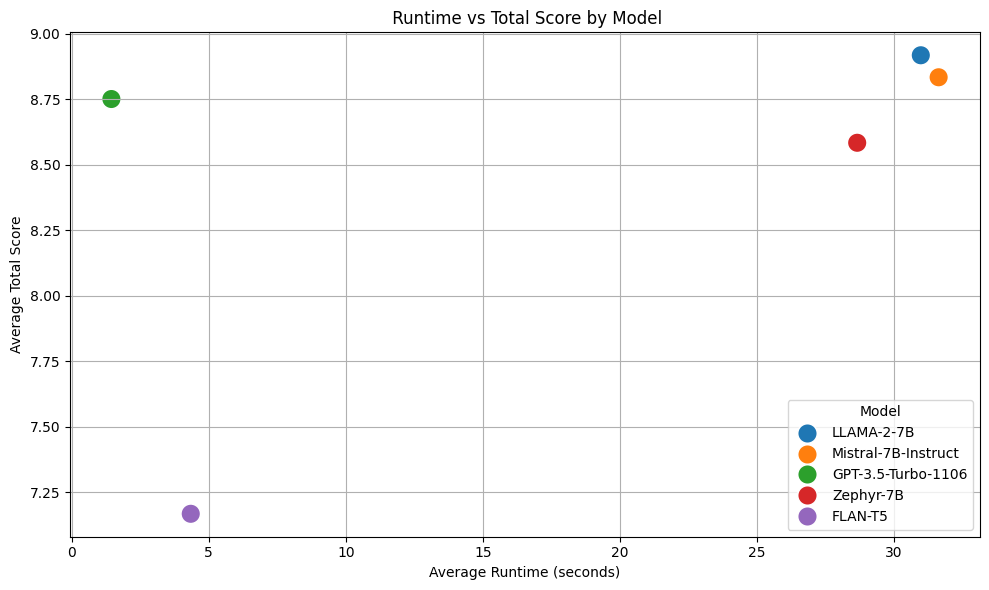

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=leaderboard, x="Runtime (s)", y="Total Score", s=200, hue=leaderboard.index)

plt.title(" Runtime vs Total Score by Model")
plt.xlabel("Average Runtime (seconds)")
plt.ylabel("Average Total Score")
plt.grid(True)
plt.tight_layout()
plt.show()


##  Runtime vs Total Score

This chart compares model speed vs. content quality.

- **GPT-3.5-Turbo**: Best balance — top score with the fastest runtime (~1.5s).
- **LLAMA-2-7B** & **Mistral-7B**: Highest scores but slow (~31s); great for batch tasks.
- **FLAN-T5**: Fast but lowest quality — not ideal without tuning.

 Use GPT-3.5 for real-time apps, Mistral or LLAMA for offline or RAG use.


2. **Bar Plot**: CTA Coverage by Model
   - Shows how effectively each model includes marketing call-to-actions.
   - Helps evaluate models on business-oriented criteria (like conversion optimization).


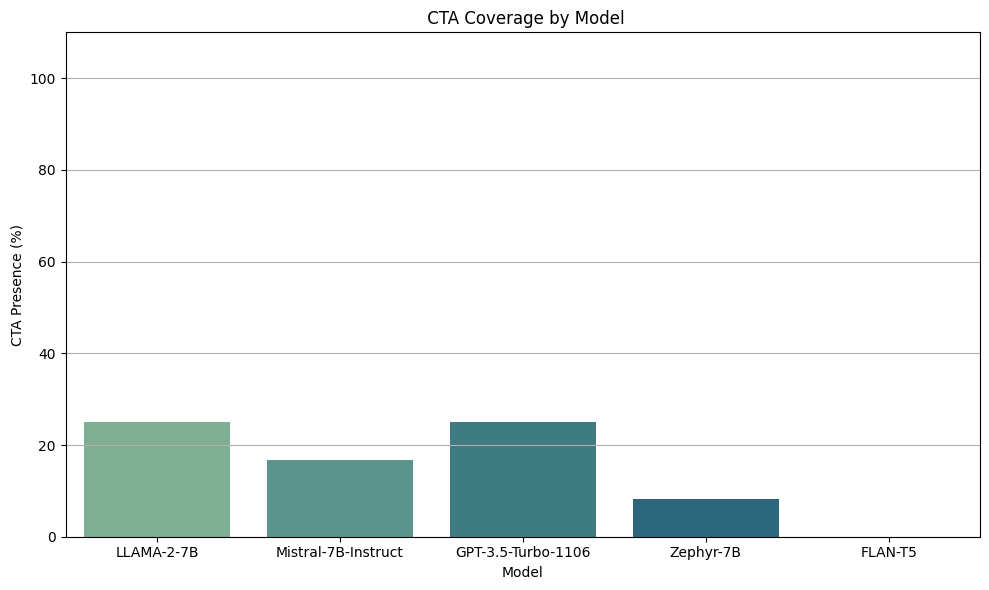

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=leaderboard.reset_index(), x="Model", y="CTA Coverage (%)", palette="crest")

plt.title(" CTA Coverage by Model")
plt.ylabel("CTA Presence (%)")
plt.xlabel("Model")
plt.ylim(0, 110)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


##  CTA Coverage by Model

This chart shows how often each model includes Calls-to-Action.

- **GPT-3.5** & **LLAMA-2-7B**: Lead with ~25% CTA presence.
- **Mistral-7B**: Moderate CTA inclusion (~17%).
- **FLAN-T5**: 0% CTA — needs major prompt tuning.

 CTA-rich outputs matter for marketing — GPT and LLAMA perform best.


## Leaderboard with BERTScore and CTA Coverage

| **Model**               | **Runtime (s)** | **Structure Score** | **Tone Score** | **Total Score** | **BERTScore F1** | **CTA Coverage (%)** |
|-------------------------|----------------:|---------------------:|----------------:|----------------:|-----------------:|----------------------:|
| **LLAMA-2-7B**          | 30.99           | 3.67                 | 5.00            |  **8.92**      | 0.811            |  **25.0**           |
| **Mistral-7B-Instruct** | 31.64           | 3.67                 | 5.00            | 8.83            |  0.831          | 16.67                |
| **GPT-3.5-Turbo-1106**  | **1.45**      | 3.50                 | 5.00            | 8.75            | **0.862**      |  **25.0**           |
| **Zephyr-7B**           | 28.66           | 3.50                 | 5.00            | 8.58            | 0.808            | 8.33                 |
| **FLAN-T5**             |  4.34         | 3.00                 | 4.17            |  7.17          |  0.786          |  0.0                 |

---

###  Key Insights

- **Best Overall (Quality + Speed)  :** GPT-3.5-Turbo-1106
  - Fastest runtime, highest BERTScore, top CTA coverage.
  - Ideal for **production-level UIs** and multilingual needs.

- **Most Reliable Open-Source**: Mistral-7B-Instruct
  - Strong BERTScore (0.831) and perfect tone scores.
  - Suitable for **fine-tuning** and **RAG** pipelines.

- **Highest CTA Presence**: LLAMA-2-7B and GPT-3.5
  - Both show strong alignment to conversion-oriented prompts.

- **Underperformer**: FLAN-T5
  - Weak CTA inclusion, lower BERTScore and tone fit.
  - Might need prompt tuning or restricted to low-stakes use cases.

---

###  Verdict

> Use **GPT-3.5-Turbo-1106** as your **primary model** for production deployment.  
> Keep **Mistral-7B-Instruct** or **LLAMA-2-7B** as a strong **fallback** for on-premise use or further fine-tuning with RAG integration.



###  Custom GPT Prompt Builder and Generator

This section defines a simplified workflow for generating marketing content using **GPT-3.5-Turbo** based on flexible input parameters.




####  build_gpt_prompt() Function
- Constructs a prompt dynamically using:
  - **Product description**
  - **Content format** (e.g., Email, Instagram post)
  - **Tone** (e.g., friendly, persuasive)
  - **Language** (e.g., English, Spanish)
- Ensures the prompt encourages:
  - Highlighting benefits
  - Using the desired tone
  - Ending with a **Call-to-Action (CTA)**



In [ ]:
def build_gpt_prompt(description, format_type, tone, language):
    return (
        f"Write a {format_type} in {language} to promote the following product:\n\n"
        f"{description}\n\n"
        f"Use a {tone.lower()} tone. Highlight key benefits and include a strong call-to-action.\n"
        f"Only output the final content."
    )


####  GPT-3.5-Turbo Integration
- Uses OpenAI's chat completion API with:
  - A system role describing the assistant as a *multilingual marketing copywriter*
  - A user message containing the custom-built prompt
- Model parameters:
  - temperature=0.7: Balanced creativity
  - max_tokens=300: Allows rich, detailed responses



In [ ]:
from openai import OpenAI
import os
import getpass

# Get the OpenAI API key from the environment variable or prompt the user to enter it
api_key = os.getenv("OPENAI_API_KEY")
if api_key is None:
    api_key = getpass.getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


In [ ]:
client = OpenAI(api_key=api_key)

def generate_with_gpt(prompt, model="gpt-3.5-turbo-1106"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You are a professional multilingual marketing copywriter."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=300
    )
    return response.choices[0].message.content.strip()


####  Example Invocation
- Generates an **Email** in **English** using a **friendly and persuasive** tone to promote a **fitness app with personalized workouts and meal planning**.
- Output is printed in a clean format.

This modular design is ideal for plugging into a UI or batch-processing pipeline.

In [ ]:
description = "A fitness app with personalized workouts and meal planning."
format_type = "Email"
tone = "Friendly and persuasive"
language = "English"

prompt = build_gpt_prompt(description, format_type, tone, language)
output = generate_with_gpt(prompt)
print("📢 GPT Output:\n", output)


📢 GPT Output:
 Subject: Get Fit and Stay Healthy with Our Personalized Fitness App!

Hey there!

Are you ready to take your fitness journey to the next level? Look no further than our cutting-edge fitness app! Whether you're aiming to shed a few pounds, build muscle, or simply improve your overall health, our app has got you covered.

Here's why you'll love it:
- Personalized Workouts: Say goodbye to cookie-cutter routines! Our app creates custom workouts tailored to your fitness level, goals, and preferences.
- Meal Planning: We believe that nutrition is just as important as exercise. That's why our app also offers personalized meal plans to help you fuel your body with the right balance of nutrients.
- Easy to Use: With a user-friendly interface and clear instructions, our app makes it a breeze to stay on track and make progress.
- Track Your Progress: Keep tabs on your fitness journey with our progress tracking feature. Celebrate your achievements and stay motivated to reach new goa

### 8️ RAG-Enhanced Content Generation with GPT-3.5

This section enhances GPT-3.5-Turbo's generation quality using **contextual retrieval** from a custom FAISS vector store built on existing marketing content.















####  Step 1: Install & Import Dependencies
- Installs key libraries: langchain, faiss-cpu, sentence-transformers, openai
- Imports tools for:
  - Document loading and chunking (TextLoader, CharacterTextSplitter)
  - Embedding (HuggingFaceEmbeddings)
  - Vector search (FAISS)

In [ ]:
!pip install -q langchain faiss-cpu sentence-transformers openai
!pip install -U langchain-community

from langchain.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.document_loaders import TextLoader
from langchain.text_splitter import CharacterTextSplitter
from openai import OpenAI
import os


####  Step 2: Build Vector Store from Domain-Specific Content
- Loads raw text files for 4 content types:
  - marketing_emails.txt
  - instagram_captions.txt
  - linkedin_posts.txt
  - whatsapp_messages.txt
- Splits content into overlapping 500-character chunks
- Embeds chunks using all-MiniLM-L6-v2 (Sentence Transformers)
- Saves a FAISS vector store per content type (one index per format)

In [ ]:
from langchain.document_loaders import TextLoader
from langchain.vectorstores import FAISS
from langchain.text_splitter import CharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/DATA690/data /rag_raw"
formats = {
    "Email": "marketing_emails.txt",
    "Instagram": "instagram_captions.txt",
    "LinkedIn": "linkedin_posts.txt",
    "WhatsApp": "whatsapp_messages.txt"
}

embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

for fmt, file in formats.items():
    loader = TextLoader(os.path.join(base_path, file))
    docs = loader.load()
    chunks = CharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)

    vecstore = FAISS.from_documents(chunks, embedding)
    vecstore.save_local(f"/content/drive/MyDrive/Colab Notebooks/DATA690/faiss_index_{fmt.lower()}")
    print(f"Indexed {fmt}")



Indexed Email
Indexed Instagram
Indexed LinkedIn
Indexed WhatsApp


####  Step 3: RAG Workflow
##### retrieve_context_by_format(query, format_type, k=3)
- Loads the corresponding FAISS index based on content format
- Retrieves **top-k** relevant chunks using semantic similarity

##### generate_rag_gpt_response(...)
- Builds a **GPT prompt with contextual grounding**
  - Includes retrieved chunks as "Context"
  - Describes the product and desired tone
- Sends prompt to GPT-3.5-Turbo
- Outputs high-relevance, tone-aligned content enriched with examples

In [ ]:
def retrieve_context_by_format(query, format_type, k=3):
    index_path = f"/content/drive/MyDrive/Colab Notebooks/DATA690/faiss_index_{format_type.lower()}"
    vectorstore = FAISS.load_local(index_path, embedding, allow_dangerous_deserialization=True)
    docs = vectorstore.similarity_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in docs])


In [ ]:
def generate_rag_gpt_response(
    product,
    description,
    format_type,
    tone,
    language,
    k=3
):
    query = product  # or description
    context = retrieve_context_by_format(query, format_type, k=k)

    prompt = (
        f"Context:\n{context}\n\n"
        f"Write a {format_type} in {language} to promote the following product:\n\n"
        f"{description}\n\n"
        f"Use a {tone.lower()} tone. Highlight key benefits and include a strong call-to-action."
    )

    response = client.chat.completions.create(
        model="gpt-3.5-turbo-1106",
        messages=[
            {"role": "system", "content": "You are a multilingual marketing copywriter."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=300
    )

    return response.choices[0].message.content.strip()


####  Example: RAG-Enhanced Instagram Caption
Generates an **Instagram** post in **English** with a **friendly and persuasive** tone for the product:
> *"FitMe – A fitness app with personalized workouts and meal planning."*

By grounding generation in relevant domain examples, this setup improves **coherence**, **CTA usage**, and **alignment to platform-specific norms**.

---

 This setup is ideal for enhancing zero-shot LLM outputs using **in-domain, reusable knowledge** — perfect for applications like marketing, customer support, and educational content.

In [ ]:
output = generate_rag_gpt_response(
    product="FitMe",
    description="A fitness app with personalized workouts and meal planning.",
    format_type="Instagram",  # or "Email", "LinkedIn", "WhatsApp"
    tone="Friendly and persuasive",
    language="English"
)

print(" GPT Output:\n", output)


 GPT Output:
 "Ready to crush your fitness goals and eat healthier? 🏋️‍♀️🍲 Our fitness app has got you covered with personalized workouts and meal planning, so you can get fit and feel great! 💪📲 Say goodbye to excuses and hello to a healthier you. Download our app now and start your fitness journey today! #FitLife #MealPlanning #WorkoutMotivation"


##  Conclusion

The benchmarking study reveals key trade-offs between performance, output quality, and business alignment:

- **GPT-3.5-Turbo-1106** stands out as the best **overall performer**, combining speed, semantic quality (highest BERTScore), and CTA inclusion — making it ideal for real-time UIs and multilingual content generation.
- **Mistral-7B-Instruct** offers an excellent **open-source alternative** with strong structure and tone scores, making it a great choice for RAG and fine-tuning tasks.
- **LLAMA-2-7B** achieved the **highest CTA coverage**, but its longer inference time makes it less suitable for interactive use cases without optimization.
- **FLAN-T5**, despite being lightweight and fast, underperformed across most metrics, indicating it may be best reserved for low-priority or non-critical deployments.

By combining classic evaluation metrics with semantic scoring and retrieval-augmented prompts, this study demonstrates a scalable, domain-adaptable framework for benchmarking LLMs in marketing content generation — applicable to other industries like e-commerce, education, and healthcare.
